<a href="https://colab.research.google.com/github/haiixin/csc-4888/blob/main/Lab_02_01_Point_Operations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 2.1: Point operations


In [1]:
!wget -nc -qq -O giraffe-portrait.jpg "https://www.dropbox.com/scl/fi/mzohe12b6absepe92ovq8/giraffe-portrait.jpg?rlkey=go4vawy9c7rwm1zk3lfc78vl1&dl=1"

In [33]:
import imageio
from matplotlib import pyplot as plt
import skimage

Image credit: [Petr Kratochvil](https://www.publicdomainpictures.net/en/view-image.php?image=38397&picture=giraffe-portrait)

## Exercises

1. Show the 'giraffe-portrait.jpg' image.

Show each channel separate (red, green and blue).

Show its red/green/blue histogram.  Interpret the histogram.

*Note: put your text response in a text/Markdown cell, not in code comments.*

/tmp/ipykernel_600/3633510693.py:1: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  im = imageio.imread('giraffe-portrait.jpg')


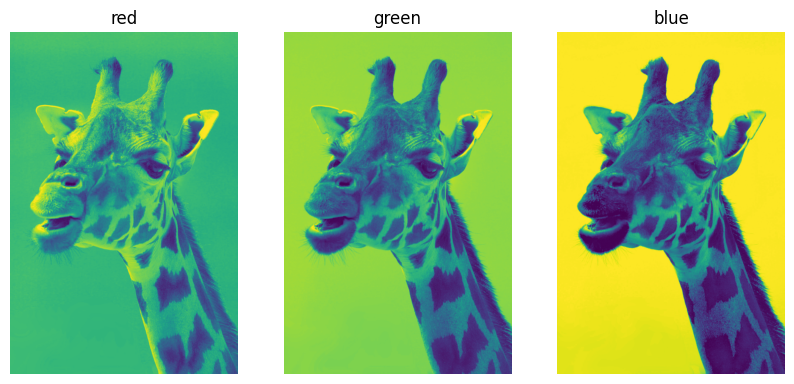

In [21]:
im = imageio.imread('giraffe-portrait.jpg')

fig, axes = plt.subplots(1, 3, figsize = (10, 20))
channels = ['red', 'green', 'blue']
for i, (ax, channel) in enumerate(zip(axes, channels)):
  ax.imshow(im[..., i])
  ax.axis('off')
  ax.set_title(channel)

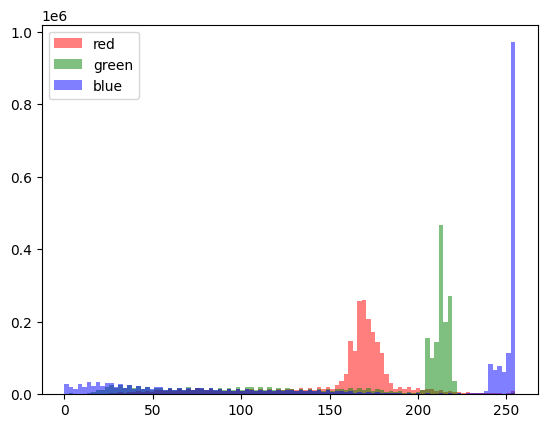

In [22]:
for i,channel in enumerate(channels):
    plt.hist(im[:,:,i].flatten(),bins=100,color=channel,alpha=0.5)
plt.legend(channels)
plt.show()

2. Invert the image (compute one minus the image) and show it.  What does this do to the colors in the image?

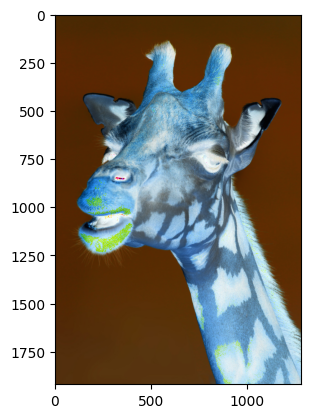

In [4]:
plt.imshow(1-im)

3. Convert the image to the [Hue Saturation Value](https://en.wikipedia.org/wiki/HSL_and_HSV) colorspace (see [`skimage.color.rgb2hsv`](https://scikit-image.org/docs/stable/auto_examples/color_exposure/plot_rgb_to_hsv.html)).

Show each channel of the HSV image (hue, saturation, and value).

Show the histograms for the HSV image.



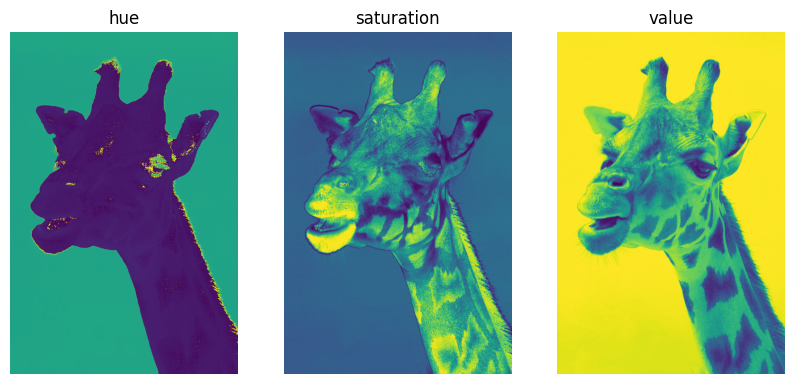

In [23]:
im_hsv = skimage.color.rgb2hsv(im)

# show each channel of hsv image
fig, axes = plt.subplots(1, 3, figsize = (10, 20))
channels = ['hue', 'saturation', 'value']
for i, (ax, channel) in enumerate(zip(axes, channels)):
  ax.imshow(im_hsv[..., i])
  ax.axis('off')
  ax.set_title(channel)


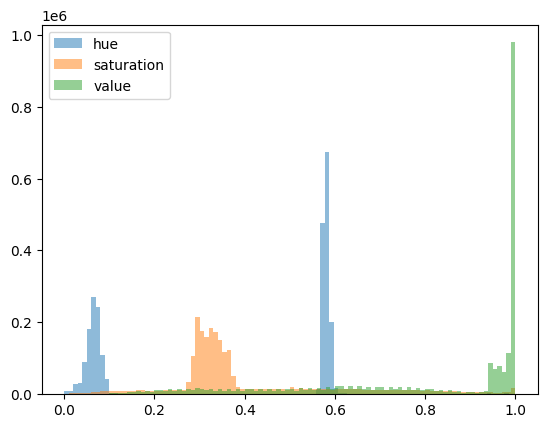

In [29]:
# show the histograms for each hsv
for i,channel in enumerate(channels):
    plt.hist(im_hsv[:,:,i].flatten(),bins=100,alpha=0.5)
plt.legend(channels)
plt.show()

5. Identify which channel provides the best background/foreground segmentation by applying Otsu's method to each channel and showing the results.  Interpret (qualitatively) which channel seems to work best.

*Note:* For this image, you will want to label the pixels *less than* the threshold as the foreground, i.e. `mask = channel < thresh`.

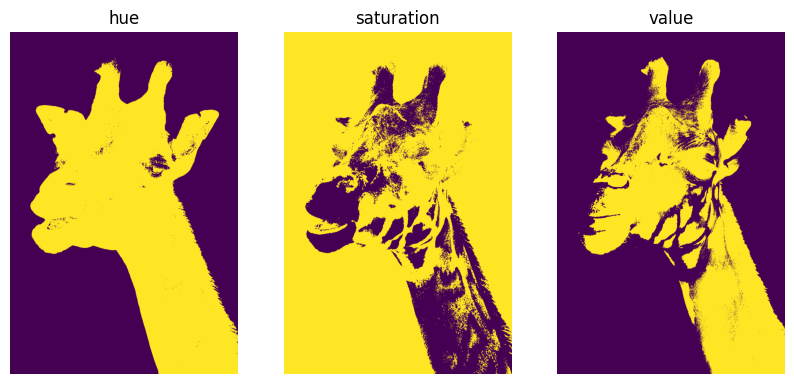

In [43]:
fig, axes = plt.subplots(1, 3, figsize = (10, 20))
for i, (ax, channel) in enumerate(zip(axes, channels)):
  channel_im = im_hsv[:, :, i]
  optimal_thresh = skimage.filters.threshold_otsu(channel_im)
  mask = channel_im < optimal_thresh
  ax.imshow(mask)
  ax.set_title(channel)
  ax.axis("off")

6. Using the channel you selected, clean up your segmentation applying the morphological "closing" operation (`skimage.morphology.closing`).  Set the `footprint` argument to a disk of radius 20 (`skimage.morphology.disk`).

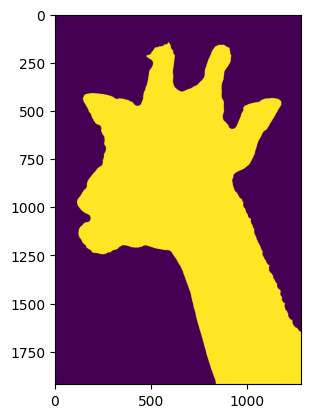

In [51]:
best_channel = im_hsv[:, :, 0]
optimal_thresh = skimage.filters.threshold_otsu(best_channel)
mask = best_channel < optimal_thresh

footprint = skimage.morphology.disk(20)

closed_im = skimage.morphology.binary_closing(mask, footprint)

plt.imshow(closed_im)

7. Show the final segmentation result by setting the background pixels of the original image to white.

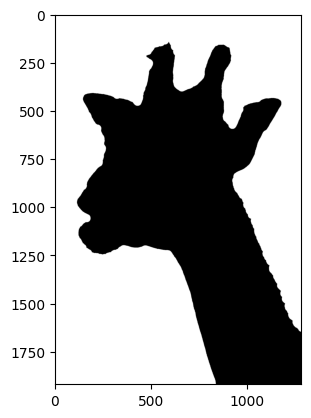

In [53]:
plt.imshow(1 - closed_im, cmap="gray")